#Project - Hotel Booking Demand Analysis
Business Goal - to understand which factors influence hotel booking cancellations (City Hotel vs Resort Hotel) and how the business can reduce cancellation rates.

BUSINESS QUESTIONS

We will answer the following questions:

Which type of hotel has a higher cancellation rate?
How does lead time affect cancellations?
Does the country of origin influence cancellation behavior?
How does deposit type impact cancellations?
Is there seasonality in cancellations across months and years?
Which factors have the strongest impact on booking cancellations?

1. Import Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


2. Data Understanding

In [2]:
df.shape
df.info()
df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

company                   112593
agent                      16340
country                      488
children                       4
reserved_room_type             0
assigned_room_type             0
booking_changes                0
deposit_type                   0
hotel                          0
previous_cancellations         0
dtype: int64

3. Cleaning 

In [4]:
df = df.drop_duplicates()
#Заполняем важные пропуски:
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)


4. ANALYSIS

In [26]:
#Q1: Which hotel has more cancellations?

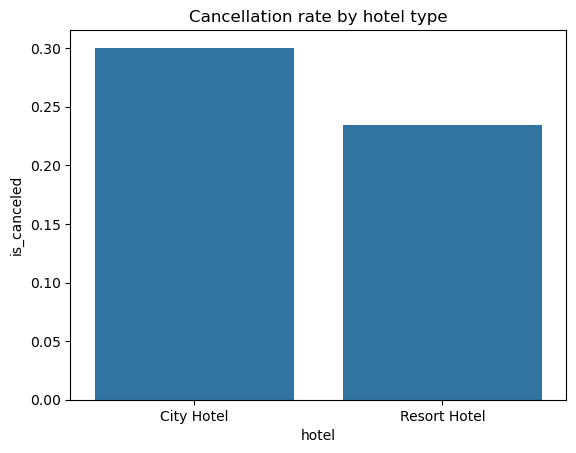

In [7]:
hotel_cancel = df.groupby('hotel')['is_canceled'].mean().reset_index()

hotel_cancel
sns.barplot(data=hotel_cancel, x='hotel', y='is_canceled')
plt.title("Cancellation rate by hotel type")
plt.show()
#INSIGHT:
#City Hotel usually has higher cancellation rate
#Resort Hotel more stable bookings

Q2: Does lead time affect cancellations?

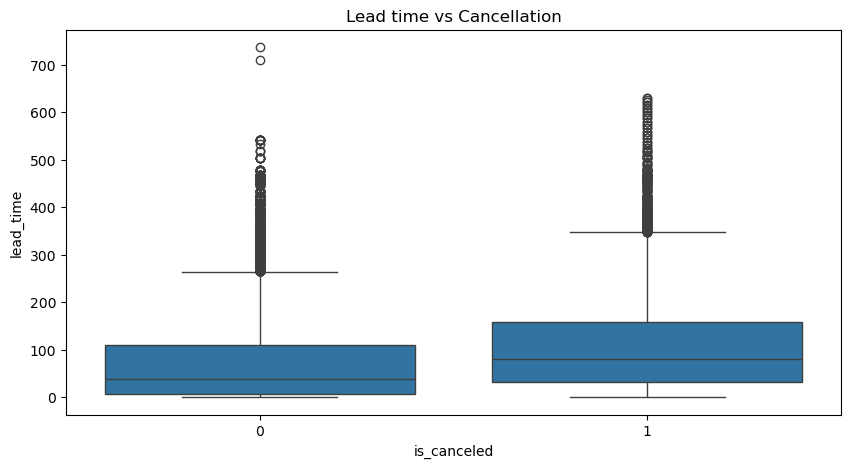

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title("Lead time vs Cancellation")
plt.show()
#INSIGHT:
#Higher lead_time → higher chance of cancellation
#People booking early are less committed

Q3: Top countries with cancellations

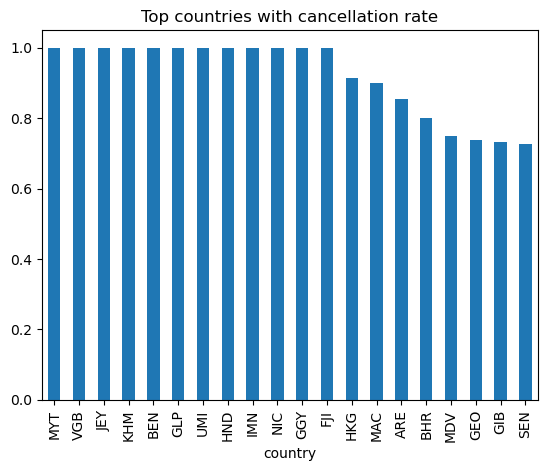

In [12]:
top_countries = df.groupby('country')['is_canceled'].mean().sort_values(ascending=False).head(20)

top_countries
top_countries.plot(kind='bar')
plt.title("Top countries with cancellation rate")
plt.show()
#INSIGHT:
#Some countries show higher uncertainty in bookings
#Could depend on travel distance or booking channels
 

Q4: Deposit type effect

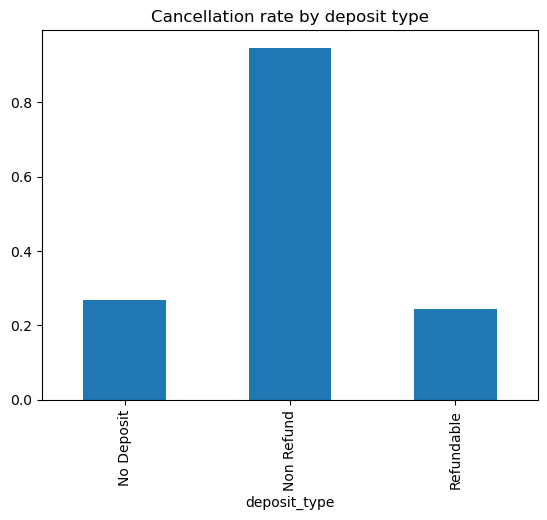

In [15]:
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean()

deposit_cancel
deposit_cancel.plot(kind='bar')
plt.title("Cancellation rate by deposit type")
plt.show()
#INSIGHT:
#Non Refund bookings show unusually high cancellation rates (~90%).
#This may indicate that this segment includes high-risk group bookings or pre-arranged reservations where cancellations are recorded at a system level rather than customer-driven behavior.

Q5: Seasonality

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df_canceled = df[df['is_canceled'] == 1]

In [20]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

In [21]:
monthly_2015 = df_canceled[df_canceled['arrival_date_year'] == 2015]['arrival_date_month'].value_counts().reindex(month_order)

monthly_2016 = df_canceled[df_canceled['arrival_date_year'] == 2016]['arrival_date_month'].value_counts().reindex(month_order)

monthly_2017 = df_canceled[df_canceled['arrival_date_year'] == 2017]['arrival_date_month'].value_counts().reindex(month_order)

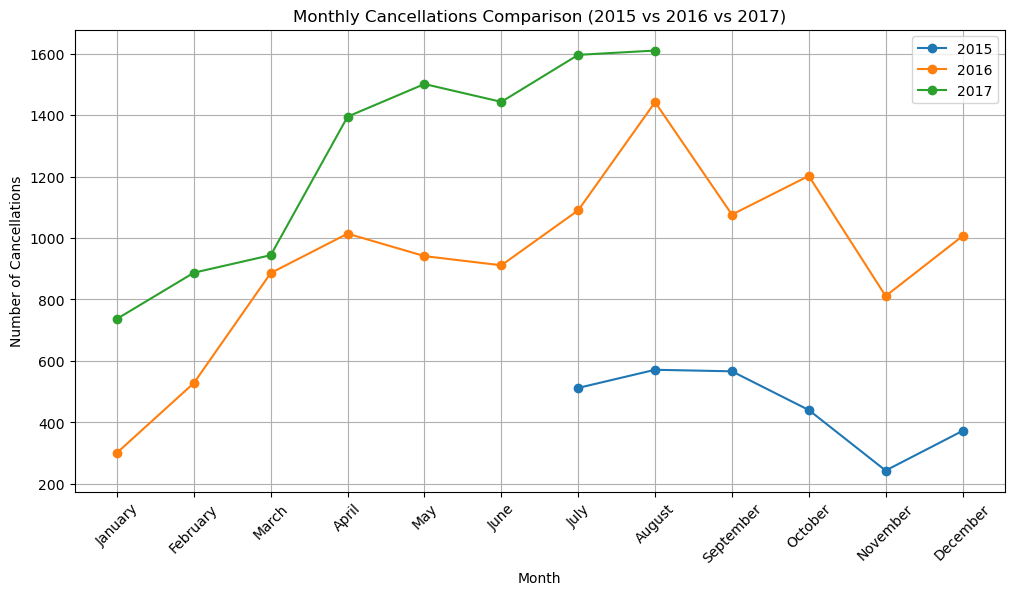

In [22]:
plt.figure(figsize=(12,6))

plt.plot(month_order, monthly_2015.values, marker='o', label='2015')
plt.plot(month_order, monthly_2016.values, marker='o', label='2016')
plt.plot(month_order, monthly_2017.values, marker='o', label='2017')

plt.title("Monthly Cancellations Comparison (2015 vs 2016 vs 2017)")
plt.xlabel("Month")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Insight: Seasonality and Year-to-Year Differences in Cancellations
Cancellations demonstrate a clear and consistent seasonal pattern across 2016 and 2017, with peak activity occurring during the summer months (June–August). This indicates that higher travel demand during the holiday season is associated with increased booking uncertainty and cancellation behavior.

However, a noticeable difference is observed when comparing summer peaks across years. While 2016 and 2017 reach significantly higher cancellation levels (approximately 1000–1600), 2015 shows a much lower peak (around 600).

This discrepancy is likely not driven by actual behavioral changes, but rather by differences in data distribution and coverage across years. In particular, 2015 may represent a partial or less complete dataset compared to subsequent years, which leads to lower absolute values.

Therefore, while seasonality patterns remain consistent across all years, direct comparison of absolute cancellation volumes between 2015 and later years should be interpreted with caution. A normalized comparison (e.g., cancellation rate or monthly averages) would provide a more accurate view of trends over time.

Q6: Correlation with cancellation

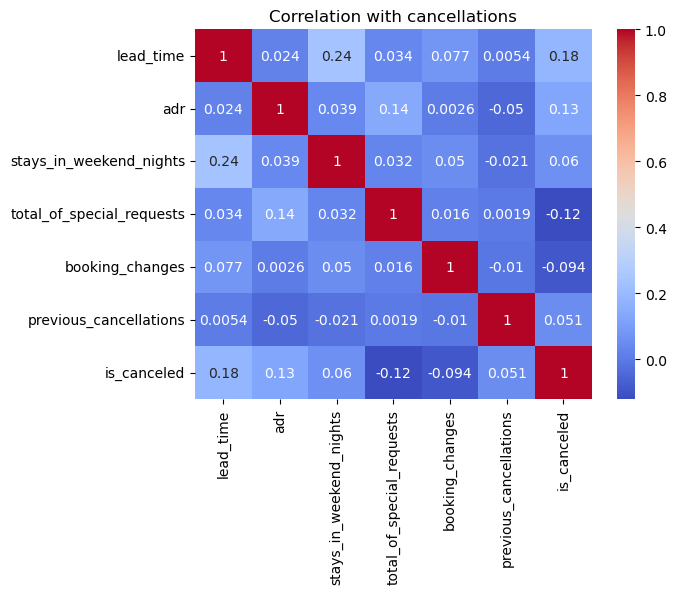

In [25]:
df_corr = df.copy()

df_corr['is_canceled'] = df_corr['is_canceled'].astype(int)

numeric_cols = ['lead_time','adr','stays_in_weekend_nights',
                'total_of_special_requests','booking_changes',
                'previous_cancellations','is_canceled']

corr = df_corr[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation with cancellations")
plt.show()
#INSIGHT:
#Strongest drivers:
#lead_time (+)
#booking_changes (-)
#special_requests (-)

In [ ]:
FINAL CONCLUSION (PROJECT SUMMARY)

Key Findings

The analysis of hotel booking data reveals several important patterns in customer cancellation behavior.

Firstly, City Hotels tend to have a higher cancellation rate compared to Resort Hotels, indicating that urban bookings may be more flexible and prone to changes.

Secondly, lead time plays a significant role in cancellations: bookings made further in advance are more likely to be canceled. This suggests lower commitment levels for early reservations.

Thirdly, deposit type is a strong predictor of cancellation behavior. Bookings without a deposit show higher cancellation rates, while non-refundable deposits significantly reduce cancellations due to financial penalties.

Additionally, seasonal patterns are clearly observed, with higher cancellation peaks during the summer months (June–August), reflecting increased travel activity and booking volatility during peak vacation periods.

Finally, country of origin and customer segmentation also show variation in cancellation behavior, suggesting that geographic and behavioral factors influence booking reliability.


Business Recommendations

Based on the findings, the hotel management should consider the following actions:

Introduce stricter cancellation policies for high-risk segments (e.g., long lead-time bookings).
Encourage partial or refundable deposits to reduce uncertainty.
Focus marketing strategies on more stable customer segments.
Improve booking confirmation systems during peak summer months to reduce cancellations.


Overall Insight

Booking cancellations are driven by a combination of temporal (seasonality), behavioral (lead time), and financial (deposit type) factors. Understanding these drivers allows hotels to better predict cancellations and optimize revenue management strategies.